In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from numba import njit

In [42]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *,bathymetry:np.ndarray, h_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        self.bathymetry = bathymetry
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']- self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [43]:
#@njit
def generate_openpit_bathymetry(
    L=500, W=500, H_max=38,
    terrace_depths=[7, 14, 21, 28, 35],
    nx=500, ny=500,
    min_terrace_width=60,   # szerokość najwyższego (najpłytszego) tarasu w metrach (po 30 m z każdej strony)
    H_wzb=10, sigma_x=5, sigma_y=5,
):
    """
    Generuje batymetrię zalanej kopalni odkrywkowej z tarasami i wizualizuje warunki początkowe.
    
    Parametry:
    -----------
    L, W           : wymiary zbiornika (m)
    H_max          : maksymalna głębokość (m)
    terrace_depths : lista głębokości kolejnych tarasów (od najgłębszego do najwyższego)
    nx, ny         : liczba punktów siatki w kierunkach x i y
    min_terrace_width : całkowita szerokość najwyższego tarasu (60 m = 30 m od brzegu z każdej strony)
    H_wzb          : amplituda początkowego wzbudzenia Gaussa na powierzchni wody (m)
    sigma_x, sigma_y : szerokości Gaussa wzbudzenia
    plot           : czy wyświetlić wizualizację 3D
    
    Zwraca:
    -------
    X, Y, Z_dna, water_surface
    """
    
    # === Siatka ===
    x = np.linspace(-L/2, L/2, nx)
    y = np.linspace(-W/2, W/2, ny)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    # === Budowa tarasów z pionowymi ścianami ===
    half_min_width = min_terrace_width / 2  # 30 m od brzegu

    for depth in terrace_depths:
        fraction = depth / H_max
        
        # Odległość od brzegu dla bieżącego tarasu (im głębszy → mniejsza)
        offset_x = half_min_width + (L/2 - min_terrace_width) * (1 - fraction)
        offset_y = half_min_width + (W/2 - min_terrace_width) * (1 - fraction)
        
        # Obszar wewnętrzny (głębszy niż bieżący taras) – zostaje bez zmian
        inner_mask = (np.abs(X) < L/2 - offset_x) & (np.abs(Y) < W/2 - offset_y)
        
        # Poza tym obszarem – ustawiamy bieżącą głębokość
        Z = np.where(inner_mask, Z, depth)

    # === Lustro wody + wzbudzenie Gaussa ===
    water = np.full_like(X, H_max)
    disturbance = H_wzb * np.exp(-(X**2/(2*sigma_x**2) + Y**2/(2*sigma_y**2)))
    water += disturbance

    return X, Y, Z, water

### Opis modelu fizycznego,numerycznego i warunków początkowych

Model przedstawia uproszczoną geometrię zalanej kopalni odkrywkowej o wymiarach  
**500 × 500 m** i maksymalnej głębokości  
**Hₘₐₓ = 38 m**.

w modelu podstawowym dno zbiornika zbudowano jako układ pięciu płaskich, poziomych tarasów o głębokościach od dna:

**7 m, 14 m, 21 m, 28 m, 35 m**

(gdzie największa wartość odpowiada najwyżej położonemu tarasowi, najbliższemu brzegom).

Tarasy oddzielone są pionowymi ścianami. Zasięg każdego tarasu w kierunkach **x** i **y** zależy liniowo od względnej głębokości **d/Hₘₐₓ** – im głębszy poziom, tym węższy (leży bliżej środka zbiornika), natomiast płytsze tarasy są szersze i sięgają bliżej krawędzi. Dzięki temu batymetria wiernie odwzorowuje typowy stożkowy profil wyrobiska odkrywkowego.

Siatka obliczeniowa ma rozdzielczość **500 × 500 punktów** (krok co 1 m).

Lustro wody w stanie spoczynku znajduje się na stałym poziomie równym maksymalnej głębokości:

**zₚₒₜ(x,y) = Hₘₐₓ = 38 m**

Na powierzchnię wody nałożono początkowe zaburzenie w postaci dwuwymiarowej funkcji Gaussa:

Δh(x,y) = H₍wzb₎ ⋅ exp(− x²/(2σₓ²) − y²/(2σᵧ²) ) 
gdzie:  
- **H₍wzb₎ = 10 m** – amplituda wzbudzenia  
- **σₓ = σᵧ = 5 m** – szerokości rozkładu Gaussa  

Zaburzenie to symuluje silny, lokalny impuls (np. zsuwisko materiału, uderzenie ufo w taflę wody) i stanowi warunek początkowy do analizy propagacji fal powierzchniowych w zbiorniku o złożonej, tarasowej batymetrii.

Model umożliwia badanie wpływu niejednorodnej głębokości (tarasów) na prędkość, odbicia i zniekształcenia rozchodzących się fal oraz ocenę potencjalnych zagrożeń w rzeczywistych zalanych odkrywkach.

### Pytanie badawcze.
Obiektem zainteresowania w projekcie jest sposób rozchodzenia się fal powstałych w kamieniołomie w wyniku uderzenia, tzn ewolucja ich kształtu oraz szybkości rozchodzenia się w zależności od ilości tarasów w kamieniołomie.

### Symulacja w stanie podstawowym

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
H_max = 38
# ==================== PARAMETRY ====================

X,Y,Z,water = generate_openpit_bathymetry()

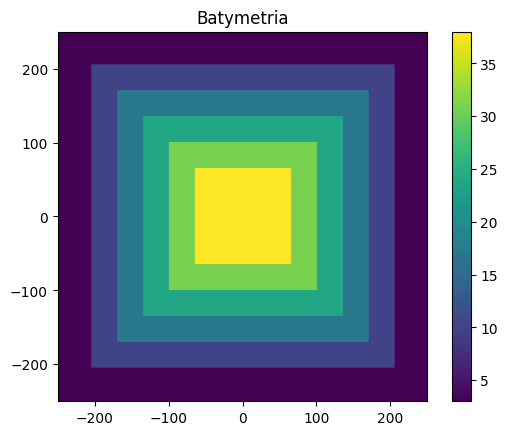

In [45]:
L=W=500
h = water - Z 
bathymetry = np.full_like(X,H_max) - Z
plt.imshow(bathymetry, extent=[-L/2, L/2, -W/2, W/2], cmap='viridis')
plt.title("Batymetria")
plt.colorbar()
plt.show()

In [46]:
output = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h
)(
    nt=60*5, g=9.81, dt_over_dxy=(0.064, 0.064), outfreq= (outputfrequency := 60)
)

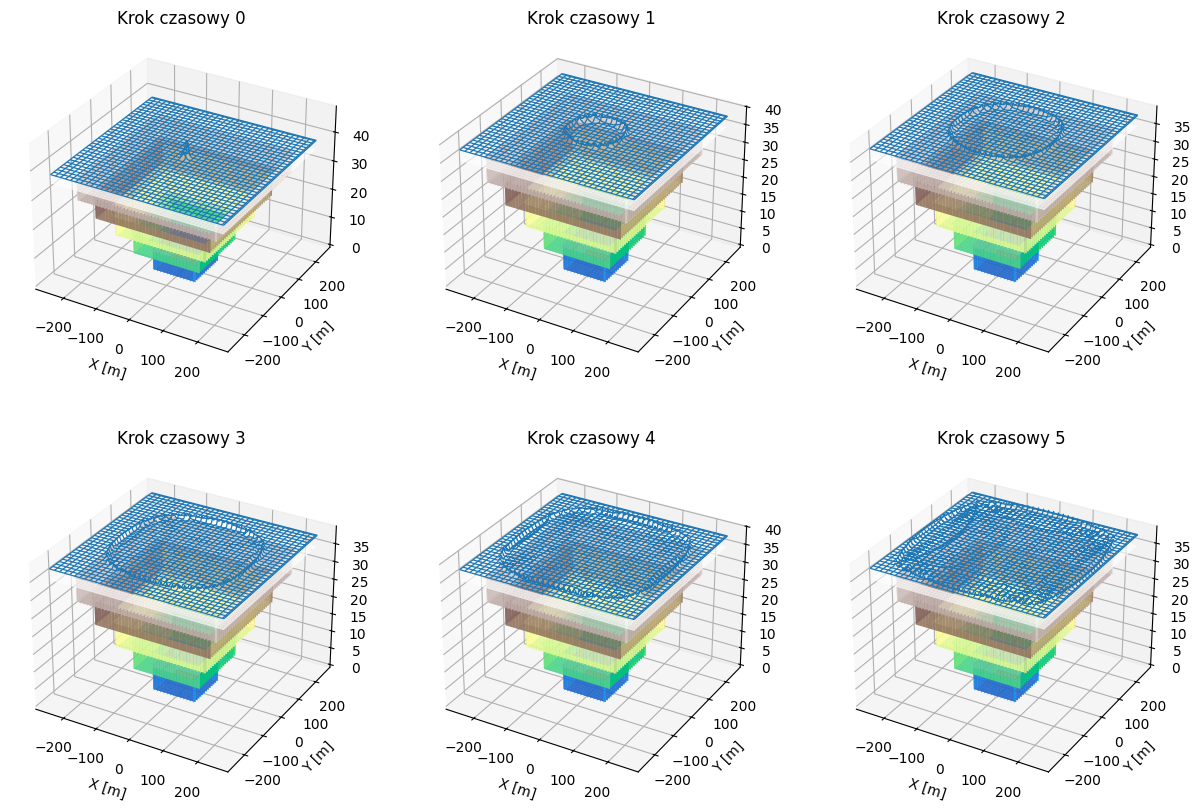

In [47]:
fig = plt.figure(figsize=(15,10))

for i, water_psi in enumerate(output['h']):
    ax = fig.add_subplot(2, len(output['h'])//2, i+1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=cm.terrain, alpha=0.7)
    ax.plot_wireframe(X, Y, water_psi - bathymetry + H_max,linewidth=0.9,rstride=15, cstride=15)
    #ax.set_zlim(0, H_max + 5)
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
plt.show()

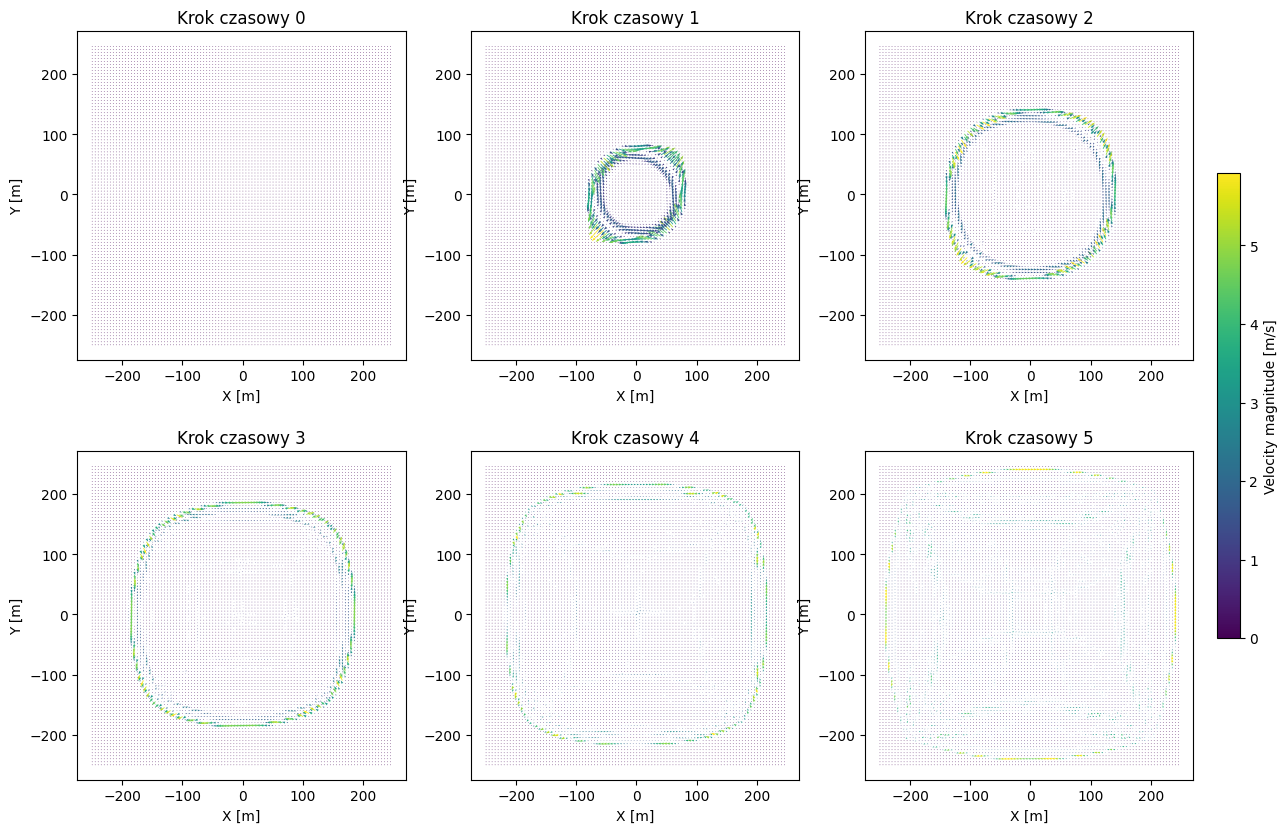

In [48]:

num_steps = len(output['uh'])
step = 5 


ncols = 3
nrows = (num_steps + ncols - 1) // ncols  

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()  
for i in range(num_steps):
    uh_t = output['uh'][i]
    vh_t = output['vh'][i]
    
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    U_sub = uh_t[::step, ::step]
    V_sub = vh_t[::step, ::step]
    
    speed = np.sqrt(U_sub**2 + V_sub**2)
    
    ax = axes[i]
    q = ax.quiver(X_sub, Y_sub, U_sub, V_sub, speed, angles='xy', scale_units='xy', scale=1, cmap='viridis')
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_aspect('equal')

for j in range(num_steps, len(axes)):
    fig.delaxes(axes[j])
cbar = fig.colorbar(q, ax=axes[:num_steps], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Velocity magnitude [m/s]')

plt.show()

### Powtórzenie powyższej symulacji z parametrami siatki o dwukrotnie większej rozdzielczości przestrzennej i czasowej

In [49]:

X,Y,Z,water = generate_openpit_bathymetry(nx=1000,ny=1000)
h = water - Z 
bathymetry = np.full_like(X,H_max) - Z

In [50]:
output = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h
)(
    nt=60*5*4, g=9.81, dt_over_dxy=(0.032, 0.032), outfreq= (outputfrequency := 60*4)
)

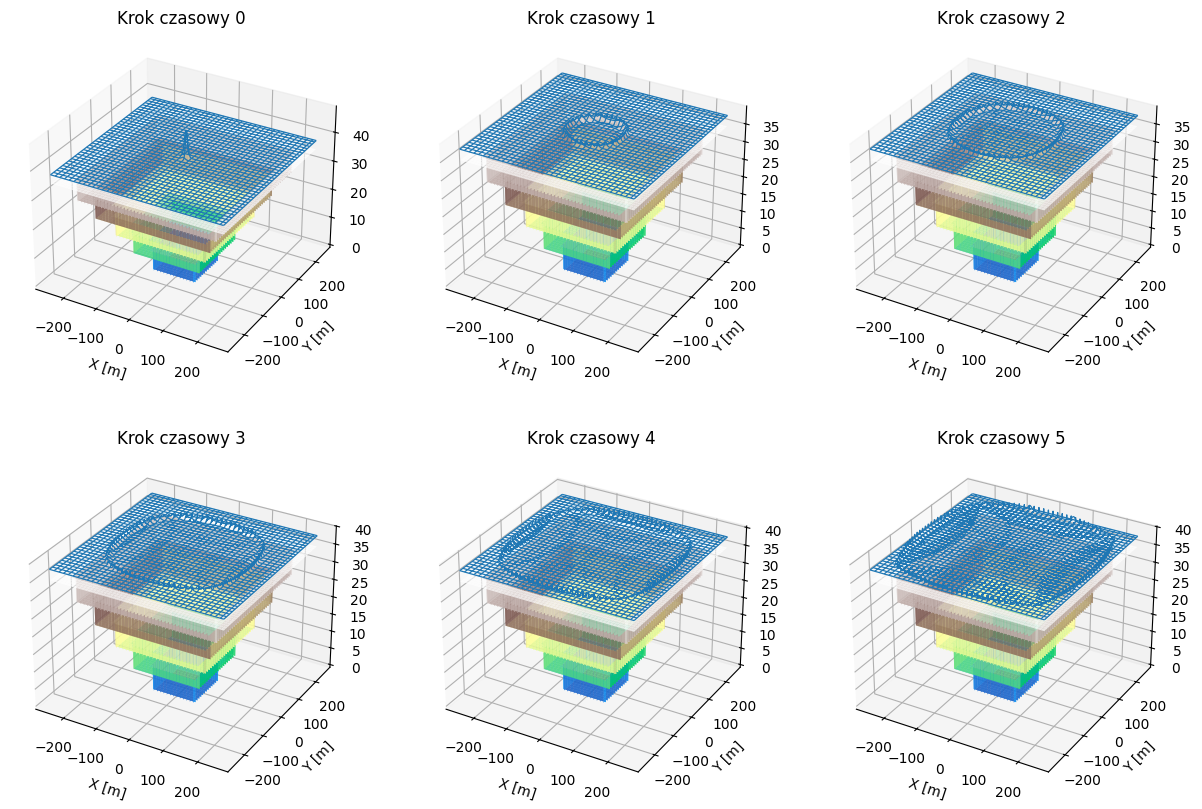

In [51]:
fig = plt.figure(figsize=(15,10))

for i, water_psi in enumerate(output['h']):
    ax = fig.add_subplot(2, len(output['h'])//2, i+1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=cm.terrain, alpha=0.7)
    ax.plot_wireframe(X, Y, water_psi - bathymetry + H_max,linewidth=0.9,rstride=14*2, cstride=14*2)
    #ax.set_zlim(0, H_max + 5)
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
plt.show()

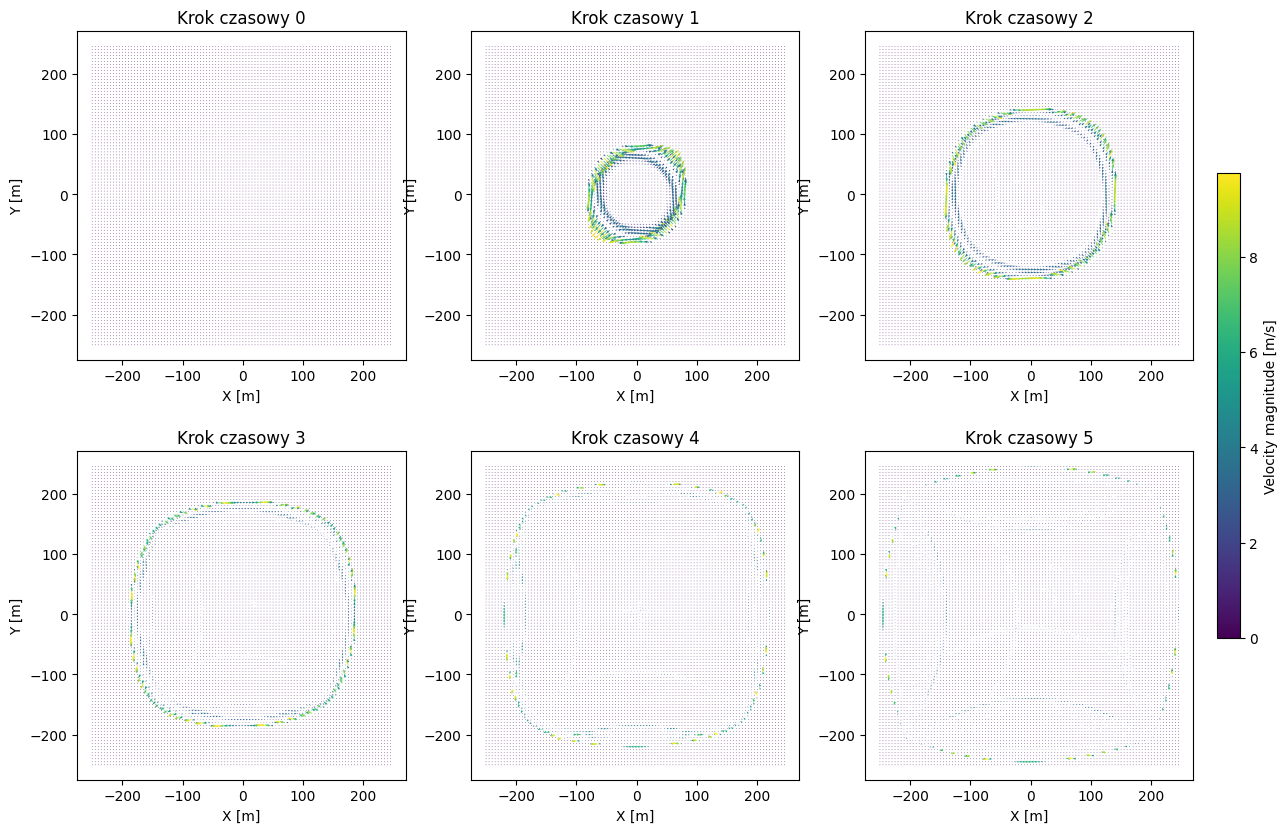

In [52]:

num_steps = len(output['uh'])
step = 10 


ncols = 3
nrows = (num_steps + ncols - 1) // ncols  

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()  
for i in range(num_steps):
    uh_t = output['uh'][i]
    vh_t = output['vh'][i]
    
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    U_sub = uh_t[::step, ::step]
    V_sub = vh_t[::step, ::step]
    
    speed = np.sqrt(U_sub**2 + V_sub**2)
    
    ax = axes[i]
    q = ax.quiver(X_sub, Y_sub, U_sub, V_sub, speed, angles='xy', scale_units='xy', scale=1, cmap='viridis')
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_aspect('equal')

for j in range(num_steps, len(axes)):
    fig.delaxes(axes[j])
cbar = fig.colorbar(q, ax=axes[:num_steps], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Velocity magnitude [m/s]')

plt.show()

Z powyższych wykresów wynika, że wyniki otrzymywane w symulacji nie różnią się w znacznym stopniu od siebie. Na tej podstawie możemy wnioskować, że nasza symulacja jest numerycznie stabilna.

### Zachowanie rozchodzącej się fali w zależności od liczby tarasów

W dalszej części pracy przeprowadzona zostanie symulacja dla układu dna z większą liczbą tarasów — odpowiednio 15 oraz 30. Tarasy te zostaną rozłożone równomiernie pomiędzy głębokościami 5 a 35 metrów, co pozwoli na analizę wpływu bardziej szczegółowej topografii dna na propagację fal w zbiorniku.


### Analiza dla 15 tarasów

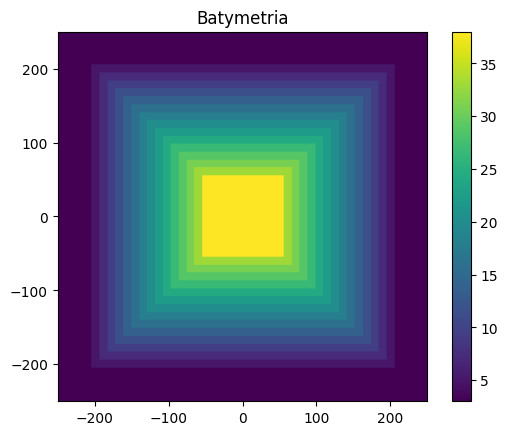

In [53]:
X,Y,Z,water = generate_openpit_bathymetry(terrace_depths=np.linspace(5,35,15))
h = water - Z 
bathymetry = np.full_like(X,H_max) - Z
plt.imshow(bathymetry, extent=[-L/2, L/2, -W/2, W/2], cmap='viridis')
plt.title("Batymetria")
plt.colorbar()
plt.show()

In [54]:
output = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h
)(
    nt=60*5, g=9.81, dt_over_dxy=(0.064, 0.064), outfreq= (outputfrequency := 60)
)

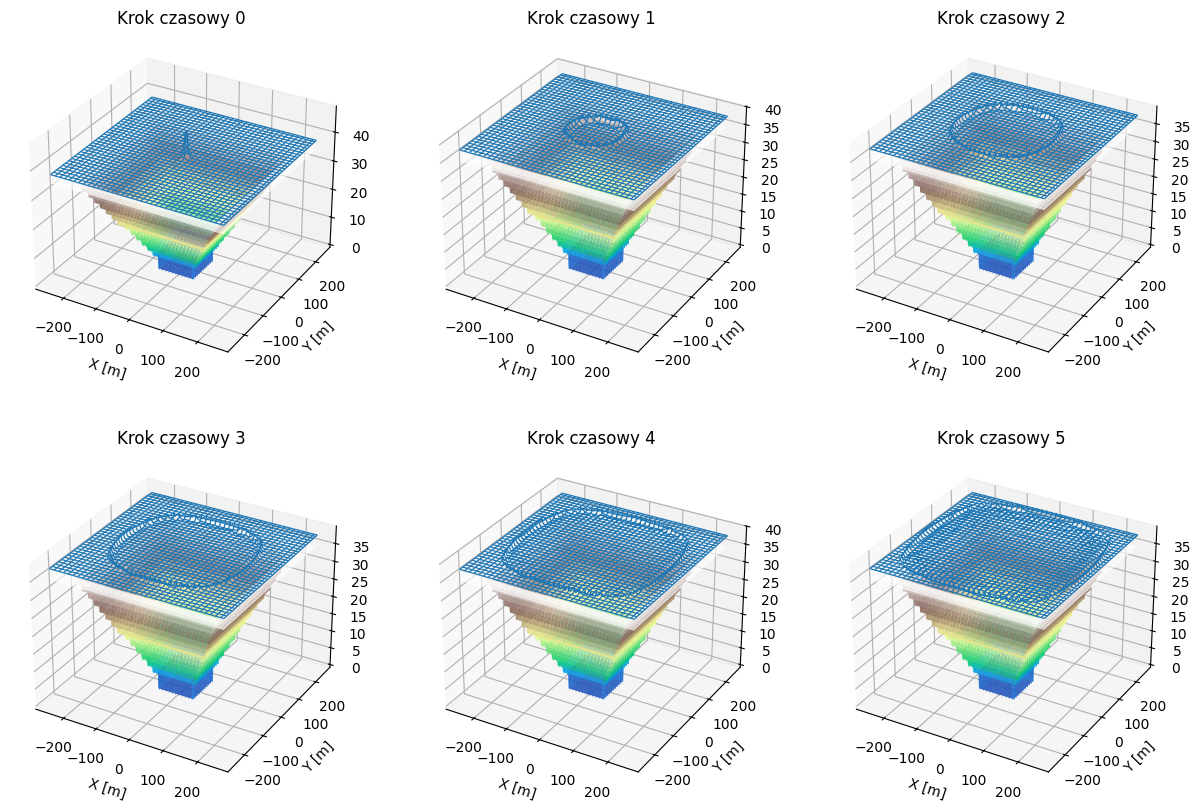

In [55]:
fig = plt.figure(figsize=(15,10))

for i, water_psi in enumerate(output['h']):
    ax = fig.add_subplot(2, len(output['h'])//2, i+1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=cm.terrain, alpha=0.7)
    ax.plot_wireframe(X, Y, water_psi - bathymetry + H_max,linewidth=0.9,rstride=14, cstride=14)
    #ax.set_zlim(0, H_max + 5)
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
plt.show()

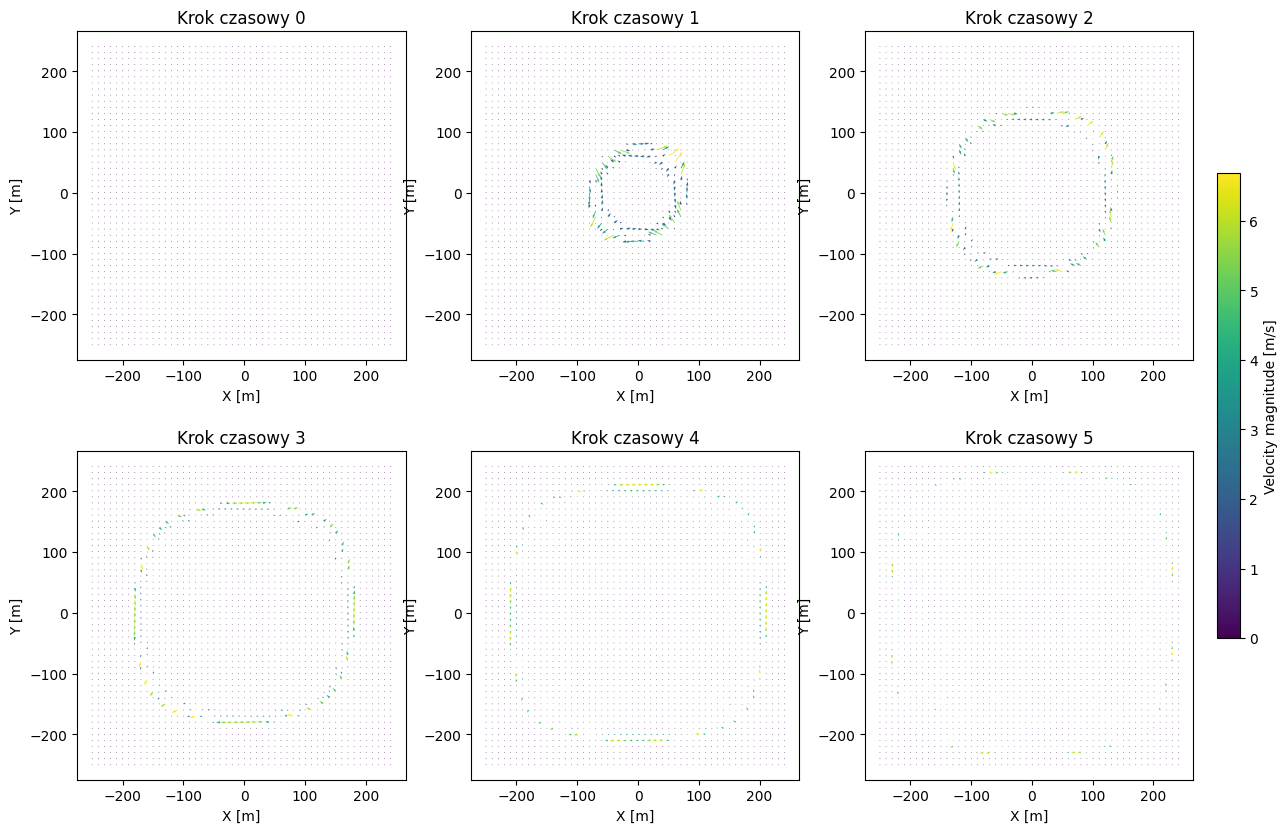

In [56]:

num_steps = len(output['uh'])
step = 10 


ncols = 3
nrows = (num_steps + ncols - 1) // ncols  

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()  
for i in range(num_steps):
    uh_t = output['uh'][i]
    vh_t = output['vh'][i]
    
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    U_sub = uh_t[::step, ::step]
    V_sub = vh_t[::step, ::step]
    
    speed = np.sqrt(U_sub**2 + V_sub**2)
    
    ax = axes[i]
    q = ax.quiver(X_sub, Y_sub, U_sub, V_sub, speed, angles='xy', scale_units='xy', scale=1, cmap='viridis')
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_aspect('equal')

for j in range(num_steps, len(axes)):
    fig.delaxes(axes[j])
cbar = fig.colorbar(q, ax=axes[:num_steps], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Velocity magnitude [m/s]')

plt.show()

W przypadku geometrii obejmującej 15 tarasów zaobserwowano, że czoło fali znacznie szybciej przybiera kształt prostokątny oraz jednocześnie dużo szybciej traci prędkość. Wynika to z dużej liczby pionowych stopni, które generują intensywne odbicia, rozpraszanie energii oraz lokalne zawirowania przepływu. Każde przejście przez taras powoduje dodatkowe hamowanie i rozpraszanie kinetyki fali, przez co jej propagacja ulega wyraźnemu spowolnieniu w porównaniu z przypadkami o prostszej geometrii. Regularne rozmieszczenie tarasów wzmacnia również interferencję fal odbitych, prowadząc do powstawania uporządkowanych, kanciastych struktur zamiast gładkiego, kołowego frontu. Obserwowany efekt jest częściowo wzmacniany przez czynniki numeryczne, takie jak dyskretyzacja siatki i stabilność czasowa schematu. Wyniki pokazują, że złożona i silnie schodkowana geometria zbiornika nie tylko zmienia kształt propagującej się fali, ale też znacząco przyspiesza jej wygaszanie i redukcję prędkości.

### Analiza dla 30 tarasów

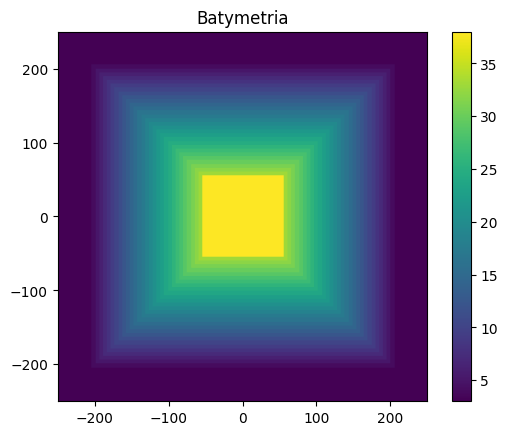

In [57]:
X,Y,Z,water = generate_openpit_bathymetry(terrace_depths=np.linspace(5,35,30))
h = water - Z 
bathymetry = np.full_like(X,H_max) - Z
plt.imshow(bathymetry, extent=[-L/2, L/2, -W/2, W/2], cmap='viridis')
plt.title("Batymetria")
plt.colorbar()
plt.show()

In [58]:
output = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h
)(
    nt=60*5, g=9.81, dt_over_dxy=(0.064, 0.064), outfreq= (outputfrequency := 60)
)

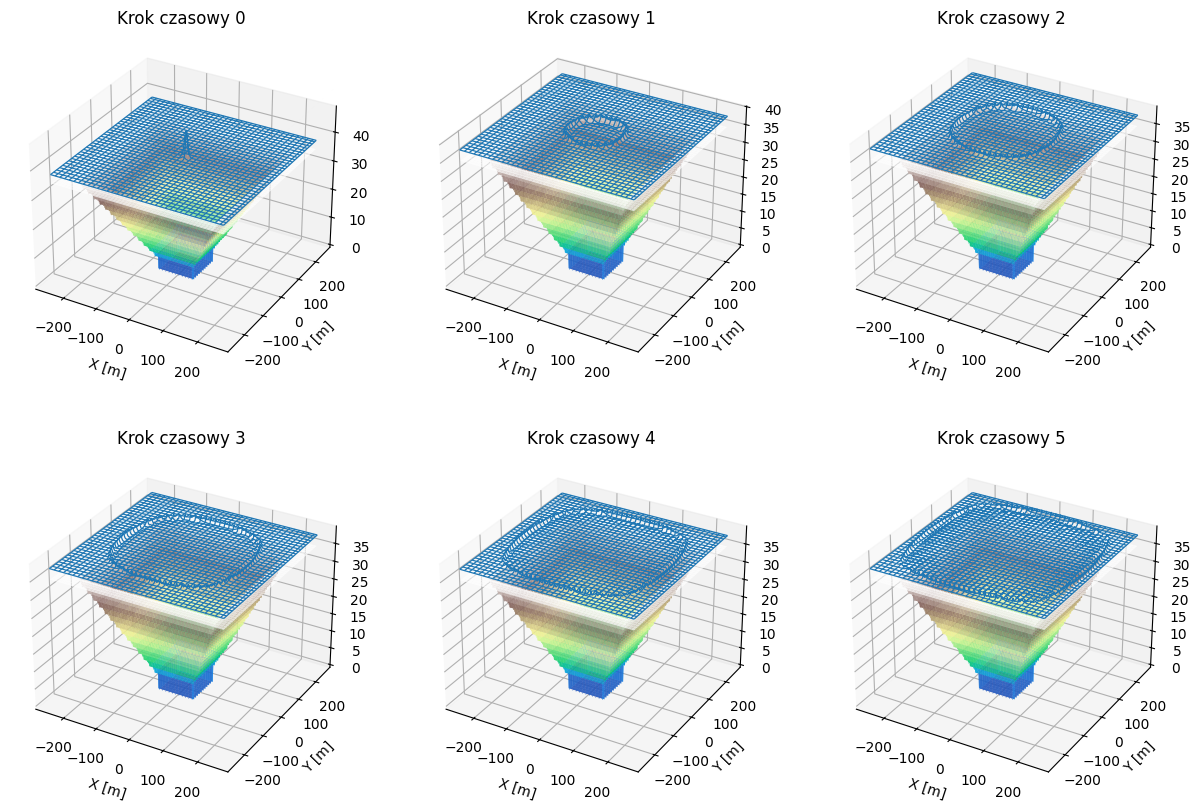

In [59]:
fig = plt.figure(figsize=(15,10))

for i, water_psi in enumerate(output['h']):
    ax = fig.add_subplot(2, len(output['h'])//2, i+1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=cm.terrain, alpha=0.7)
    ax.plot_wireframe(X, Y, water_psi - bathymetry + H_max,linewidth=0.9,rstride=14, cstride=14)
    #ax.set_zlim(0, H_max + 5)
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
plt.show()

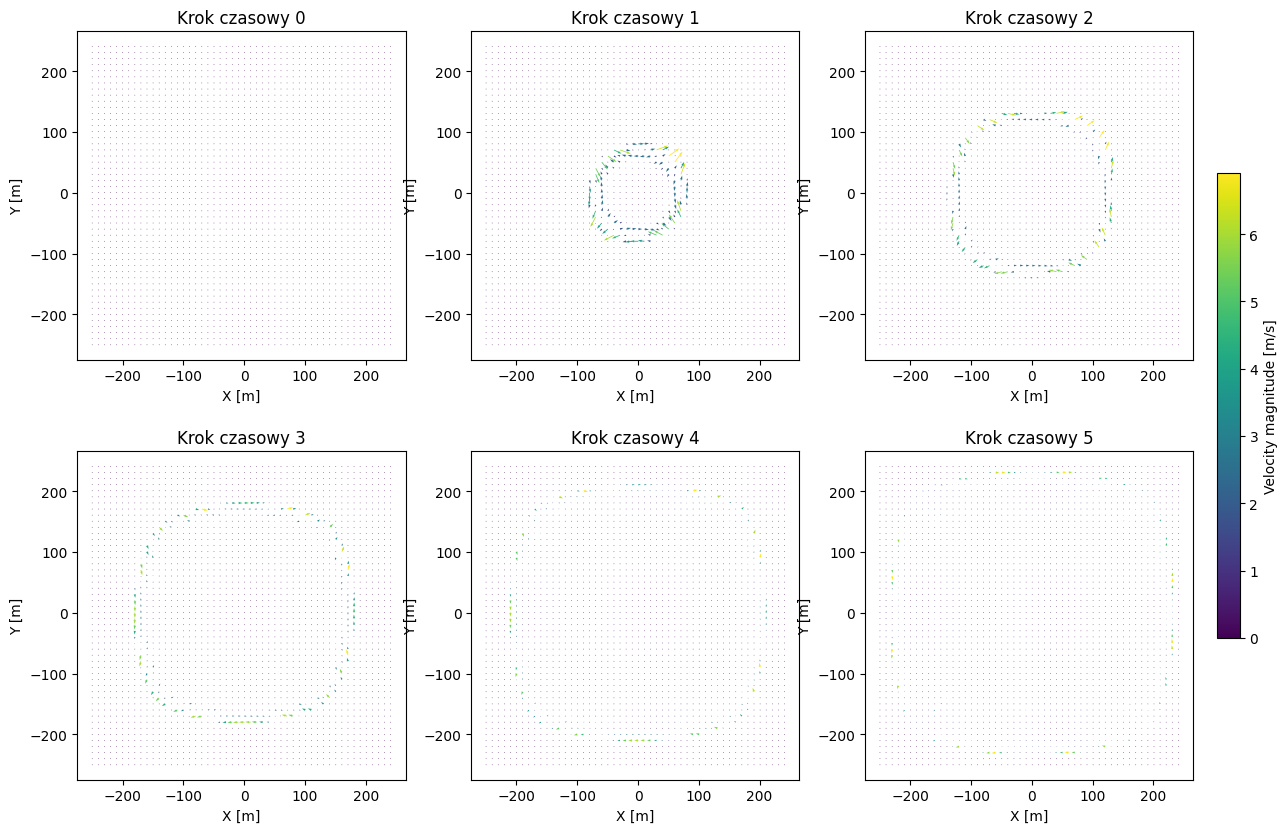

In [60]:

num_steps = len(output['uh'])
step = 10 


ncols = 3
nrows = (num_steps + ncols - 1) // ncols  

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()  
for i in range(num_steps):
    uh_t = output['uh'][i]
    vh_t = output['vh'][i]
    
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    U_sub = uh_t[::step, ::step]
    V_sub = vh_t[::step, ::step]
    
    speed = np.sqrt(U_sub**2 + V_sub**2)
    
    ax = axes[i]
    q = ax.quiver(X_sub, Y_sub, U_sub, V_sub, speed, angles='xy', scale_units='xy', scale=1, cmap='viridis')
    ax.set_title(f'Krok czasowy {i}')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_aspect('equal')

for j in range(num_steps, len(axes)):
    fig.delaxes(axes[j])
cbar = fig.colorbar(q, ax=axes[:num_steps], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Velocity magnitude [m/s]')

plt.show()

W przypadku geometrii obejmującej 30 tarasów zaobserwowano, że czoło fali jeszcze szybciej przybiera kształt prostokątny oraz jednocześnie dużo szybciej traci prędkość w porównaniu z konfiguracjami o mniejszej liczbie tarasów.

### Podsumowanie projektu
Projekt skupiał się na symulacji propagacji fal powierzchniowych w zalanej kopalni odkrywkowej, z uwzględnieniem wpływu liczby tarasów na dnie zbiornika na kształt i prędkość rozchodzenia się fal wywołanych początkowym zaburzeniem gaussowskim. Model fizyczny oparto na równaniach płytkiej wody (Shallow Water Equations), implementowanych numerycznie za pomocą biblioteki PyMPDATA, co pozwoliło na stabilne i dokładne symulacje w dwuwymiarowej siatce obliczeniowej. Warunki początkowe obejmowały zbiornik o wymiarach 500 × 500 m i maksymalnej głębokości 38 m, z tarasami rozłożonymi na różnych poziomach głębokości (od 5 do 15, a następnie do 30 tarasów).
Analiza wykazała, że zwiększanie liczby tarasów prowadzi do szybszego przekształcania frontu fali w kształt prostokątny, oraz znaczącego spowolnienia propagacji. W konfiguracji podstawowej (5 tarasów) fala zachowywała bardziej kołowy charakter i wyższą prędkość, podczas gdy w przypadkach z 15 i 30 tarasami dominowały efekty hamujące, co podkreśla rolę złożonej batymetrii w dynamice fal. Symulacje potwierdziły numeryczną stabilność modelu, w tym brak istotnych różnic przy podwajaniu rozdzielczości siatki.
Ogólny wniosek wskazuje, że w rzeczywistych zalanych wyrobiskach o schodkowej topografii, zwiększona liczba tarasów może zmniejszać ryzyko falowych zagrożeń (np. przelewania brzegów) poprzez szybkie wygaszanie energii, ale jednocześnie generować bardziej złożone wzorce interferencji. Projekt dostarcza cennych wglądów w hydrodynamikę takich systemów, z potencjalnymi zastosowaniami w inżynierii środowiska i bezpieczeństwie górniczym. Dalsze badania mogłyby uwzględnić efekty trójwymiarowe lub nieregularne zaburzenia początkowe.